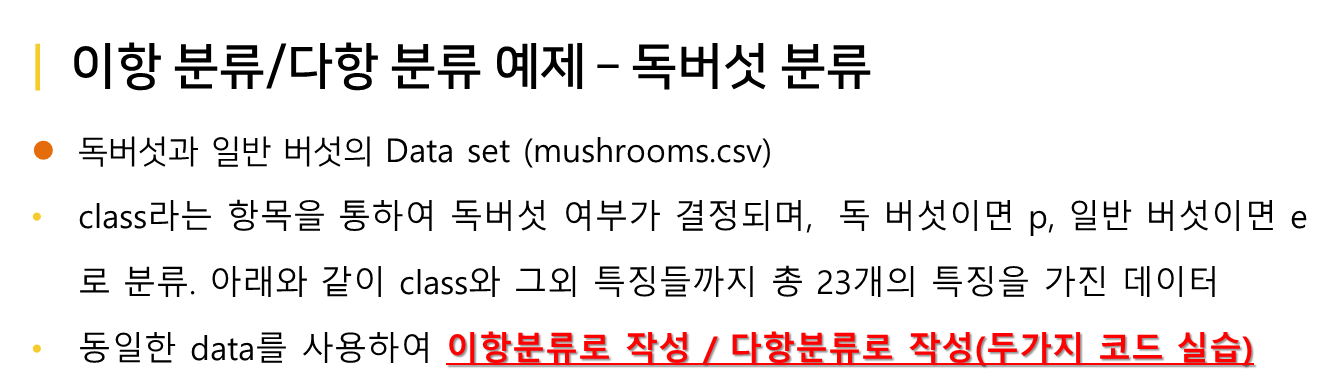

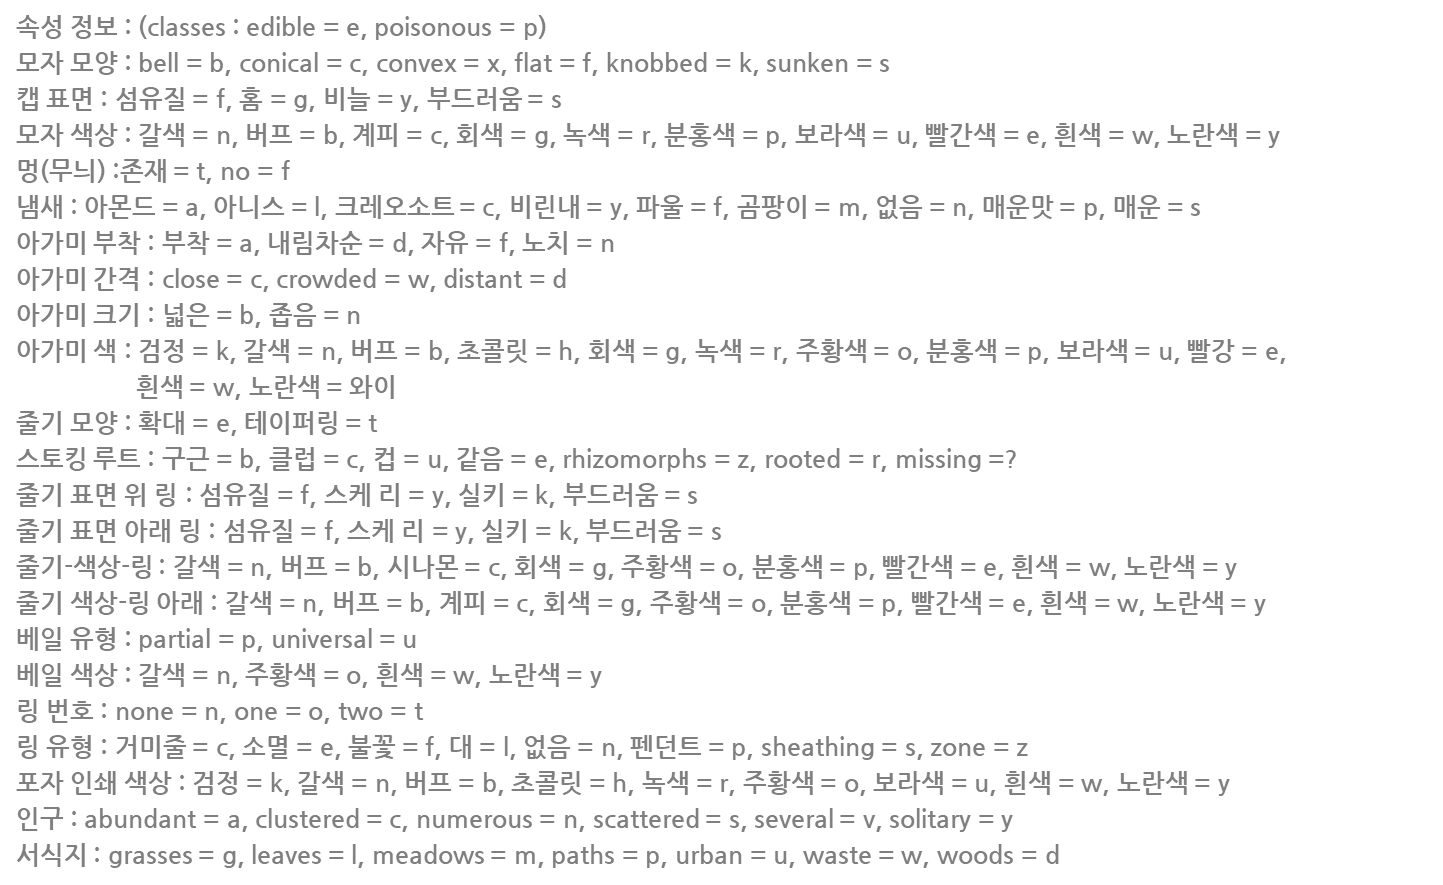

In [1]:
####################################################
# 12 2진 분류 - 독버섯 분류
####################################################
import pandas as pd 
import matplotlib.pyplot as plt
# Label Encoding - 열 단위로만 가능하므로 loop 사용
from sklearn.preprocessing import LabelEncoder 

df_mushrooms = pd.read_csv('./data/mushrooms.csv')
df_mushrooms  # classes : p 독버섯, e 일반버섯

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [2]:
# Null 이 있는지 Check -> 없음
df_mushrooms.count()

class                       8124
cap-shape                   8124
cap-surface                 8124
cap-color                   8124
bruises                     8124
odor                        8124
gill-attachment             8124
gill-spacing                8124
gill-size                   8124
gill-color                  8124
stalk-shape                 8124
stalk-root                  8124
stalk-surface-above-ring    8124
stalk-surface-below-ring    8124
stalk-color-above-ring      8124
stalk-color-below-ring      8124
veil-type                   8124
veil-color                  8124
ring-number                 8124
ring-type                   8124
spore-print-color           8124
population                  8124
habitat                     8124
dtype: int64

In [3]:
df_mushrooms.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [4]:
## 모든 문자 데이터를 LabelEncoder를 활용하여 정수형 숫자 데이터로 변환
e = LabelEncoder()
dic_classes = dict()
for col in df_mushrooms.columns:
    df_mushrooms[col] = e.fit_transform(df_mushrooms[col])        
    dic_classes[col] = e.classes_   # 숫자로 어떻게 변환되었는지 기록 
dic_classes

{'class': array(['e', 'p'], dtype=object),
 'cap-shape': array(['b', 'c', 'f', 'k', 's', 'x'], dtype=object),
 'cap-surface': array(['f', 'g', 's', 'y'], dtype=object),
 'cap-color': array(['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y'], dtype=object),
 'bruises': array(['f', 't'], dtype=object),
 'odor': array(['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y'], dtype=object),
 'gill-attachment': array(['a', 'f'], dtype=object),
 'gill-spacing': array(['c', 'w'], dtype=object),
 'gill-size': array(['b', 'n'], dtype=object),
 'gill-color': array(['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y'],
       dtype=object),
 'stalk-shape': array(['e', 't'], dtype=object),
 'stalk-root': array(['?', 'b', 'c', 'e', 'r'], dtype=object),
 'stalk-surface-above-ring': array(['f', 'k', 's', 'y'], dtype=object),
 'stalk-surface-below-ring': array(['f', 'k', 's', 'y'], dtype=object),
 'stalk-color-above-ring': array(['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y'], dtype=object),
 'stalk-color-be

In [5]:
Y = df_mushrooms['class'].values           # class열만 취함
X = df_mushrooms.iloc[:, 1:].values
X

array([[5, 2, 4, ..., 2, 3, 5],
       [5, 2, 9, ..., 3, 2, 1],
       [0, 2, 8, ..., 3, 2, 3],
       ...,
       [2, 2, 4, ..., 0, 1, 2],
       [3, 3, 4, ..., 7, 4, 2],
       [5, 2, 4, ..., 4, 1, 2]])

In [6]:
Y

array([1, 0, 0, ..., 0, 1, 0])

In [ ]:
# x = mushrooms.drop(['class'], axis=1).values   # class 열을 제외한 나머지 모든 열...
#data의 특성을 살펴보면 스케일의 차이가 심하지 않아 정규화가 필수는 아님
# X = (X - X.min()) / (X.max() - X.min())   ## x 데이터 정규화 (0~1 사이가 되도록)
# X.shape, X

In [ ]:
# X[:, 0].max()

In [ ]:
X_normalized = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0)) # Min Max 정규화
X_normalized.max(axis=0)

In [ ]:
X.max(axis=0) - X.min(axis=0)

In [ ]:
(X - X.min(axis=0)).shape

In [ ]:
X_normalized

### 이진분류 학습

In [ ]:
Y

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

#### Train data와 Test data (20%) 분리하기
x_train , x_test , y_train , y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
print("x_train.shape=", x_train.shape)
print("x_test.shape=", x_test.shape)
print("y_train.shape=", y_train.shape)
print("y_test.shape=", y_test.shape)

In [ ]:
model = Sequential()
model.add(Dense(48, input_dim=22, activation='relu'))
model.add(Dense(24, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=25, batch_size=32)
model.summary()

## test data set으로 모델 검증
model.evaluate(x_test, y_test)

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label='loss')
plt.legend()

In [ ]:
## test data로 검증
model.evaluate(x_test, y_test)   # [loss, accuracy]

In [ ]:
print("TEST SET Accuracy : %.2f" % model.evaluate(x_test, y_test)[1])

In [ ]:
x_test

In [ ]:
model.predict(x_test[10:15])

In [ ]:
model.predict(x_test[10:15])

In [ ]:
y_test[10:15]

In [ ]:
(model.predict(x_test[10:15]).flatten()>0.5) * 1

## 다중분류 학습

In [ ]:
#######################################################
# 12 다중분류로 풀어보기 - 독버섯 분류 2  
#######################################################
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 

mushrooms = pd.read_csv('./data/mushrooms.csv')

# Label Encoding - 열 단위로만 가능하므로 loop 사용
labelencoder = LabelEncoder()
for col in reversed(mushrooms.columns):
    mushrooms[col] = labelencoder.fit_transform(mushrooms[col])     

y = mushrooms['class'].values           # class열만 취함
x = mushrooms.iloc[:, 1:].values
# x = mushrooms.drop(['class'], axis=1).values   # class 열을 제외한 나머지 모든 열...
#data의 특성을 살펴보면 스케일의 차이가 심하지 않아 정규화가 필수는 아님
x = (x - x.min()) / (x.max() - x.min())   ## x 데이터 정규화 (0~1 사이가 되도록)


In [ ]:
x

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split

#### Train data와 Test data (20%) 분리하기
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state=1)
print("x_train.shape=", x_train.shape)
print("x_test.shape=", x_test.shape)
print("y_train.shape=", y_train.shape)
print("y_test.shape=", y_test.shape)

### Binary 를 Multi class 분류로... (one hot encoding!!)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=2)

print("======= to_categorical 처리 이후 =========")
print("y_train.shape=", y_train.shape)
print("y_test.shape=", y_test.shape)
y_test

In [ ]:
model = Sequential()
model.add(Dense(48, input_dim=22, activation='relu'))
model.add(Dense(24, activation='relu'))
model.add(Dense(12, activation='relu'))
model.add(Dense(2, activation='softmax'))   ### 2항으로 변경

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=30, batch_size=50)
model.summary()

## test data set으로 모델 검증
model.evaluate(x_test, y_test)

In [ ]:
model.summary()

### 학습데이터 검증

In [ ]:
## 학습 데이터셋 검증
model.evaluate(x_train, y_train)

In [ ]:
model.evaluate(x_test, y_test)

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['loss'], label='loss')
plt.legend()

In [ ]:
x_test

In [ ]:
x_test[:5]

In [ ]:
y_predict = model.predict(x_test[:5])
y_predict

In [ ]:
y_test[:5]

In [ ]:
y_test[:5].argmax(axis=1)

In [ ]:
y_predict.argmax(axis=1)  # 예측이 맞았음